In [7]:
# ==========================================================
# RELEASE METRICS DATASET GENERATION (PART 1)
# AI-Driven Test Failure Prediction System
# ==========================================================

import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

random.seed(42)
np.random.seed(42)

NUM_RELEASES = 10000

release_records = []

release_types = [
    "Major",
    "Minor",
    "Patch",
    "Hotfix"
]

applications = [
    "Internet Banking",
    "Mobile Banking",
    "Payments",
    "Cards",
    "Loans",
    "CRM",
    "Treasury",
    "Authentication"
]

deployment_windows = [
    "Business Hours",
    "Night",
    "Weekend"
]

environments = [
    "QA",
    "UAT",
    "Production"
]

release_start = datetime(2025,1,1)

for i in range(NUM_RELEASES):

    release_id = f"REL{i+1:05d}"

    application = random.choice(applications)

    release_type = random.choices(
        release_types,
        weights=[20,35,30,15],
        k=1
    )[0]

    deployment_window = random.choices(
        deployment_windows,
        weights=[20,50,30],
        k=1
    )[0]

    environment = random.choices(
        environments,
        weights=[30,30,40],
        k=1
    )[0]

    # --------------------------------------------------
    # Release Size
    # --------------------------------------------------

    if release_type == "Major":

        release_size = max(120,
                           int(np.random.normal(350,80)))

        release_complexity = random.randint(7,10)

        microservices = random.randint(12,25)

    elif release_type == "Minor":

        release_size = max(60,
                           int(np.random.normal(180,45)))

        release_complexity = random.randint(4,8)

        microservices = random.randint(8,18)

    elif release_type == "Patch":

        release_size = max(20,
                           int(np.random.normal(70,20)))

        release_complexity = random.randint(2,5)

        microservices = random.randint(3,10)

    else:

        release_size = max(5,
                           int(np.random.normal(30,10)))

        release_complexity = random.randint(1,3)

        microservices = random.randint(1,5)

    # --------------------------------------------------
    # Engineering Metrics
    # --------------------------------------------------

    team_experience = max(
        1,
        int(np.random.normal(6,2))
    )

    developer_experience = max(
        1,
        int(np.random.normal(5,2))
    )

    automation_percentage = np.clip(
        np.random.normal(78,12),
        40,
        100
    )

    code_coverage = np.clip(
        np.random.normal(82,8),
        50,
        98
    )

    pass_rate = np.clip(
        np.random.normal(90,6),
        60,
        100
    )

    defect_density = max(
        0.2,
        np.random.normal(4.5,2)
    )

    technical_debt = max(
        1,
        int(np.random.normal(18,8))
    )

    security_findings = np.random.poisson(2)

    failed_tests = max(
        0,
        int(np.random.normal(45,18))
    )

    deployment_duration = max(
        20,
        int(np.random.normal(90,30))
    )

    rollback_count = min(
        np.random.poisson(1),
        4
    )

    production_incidents = min(
        np.random.poisson(1),
        5
    )

    hotfix_count = min(
        np.random.poisson(2),
        6
    )

    requirement_volatility = random.randint(1,10)

    integration_complexity = random.randint(1,10)

    environment_stability = random.randint(1,10)

    release_date = release_start + timedelta(
        days=random.randint(0,365)
    )

    release_records.append([

        release_id,

        application,

        release_type,

        deployment_window,

        environment,

        release_size,

        release_complexity,

        microservices,

        team_experience,

        developer_experience,

        automation_percentage,

        code_coverage,

        pass_rate,

        defect_density,

        technical_debt,

        security_findings,

        failed_tests,

        deployment_duration,

        rollback_count,

        production_incidents,

        hotfix_count,

        requirement_volatility,

        integration_complexity,

        environment_stability,

        release_date

    ])

print("Generated Releases :", len(release_records))

Generated Releases : 10000


In [8]:
# ==========================================================
# PART 2
# DATAFRAME CREATION + FEATURE ENGINEERING
# ==========================================================

release_df = pd.DataFrame(

    release_records,

    columns=[

        "release_id",

        "application",

        "release_type",

        "deployment_window",

        "environment",

        "release_size",

        "release_complexity",

        "microservices",

        "team_experience",

        "developer_experience",

        "automation_percentage",

        "code_coverage",

        "pass_rate",

        "defect_density",

        "technical_debt",

        "security_findings",

        "failed_tests",

        "deployment_duration",

        "rollback_count",

        "production_incidents",

        "hotfix_count",

        "requirement_volatility",

        "integration_complexity",

        "environment_stability",

        "release_date"

    ]

)

print("Dataset Shape :", release_df.shape)

# ==========================================================
# FEATURE ENGINEERING
# ==========================================================

# Quality Index

release_df["quality_index"] = (

    release_df["code_coverage"] *

    release_df["pass_rate"]

) / (

    release_df["defect_density"] + 1

)

# Deployment Efficiency

release_df["deployment_efficiency"] = (

    release_df["automation_percentage"]

) / (

    release_df["deployment_duration"]

)

# Risk Density

release_df["risk_density"] = (

    release_df["defect_density"] *

    release_df["release_complexity"]

) / (

    release_df["team_experience"] + 1

)

# Incident Ratio

release_df["incident_ratio"] = (

    release_df["production_incidents"]

) / (

    release_df["release_size"] + 1

)

# Test Effectiveness

release_df["test_effectiveness"] = (

    release_df["pass_rate"]

) / (

    release_df["failed_tests"] + 1

)

# Automation Score

release_df["automation_score"] = (

    release_df["automation_percentage"] *

    release_df["code_coverage"]

) / 100

# Technical Debt Index

release_df["technical_debt_index"] = (

    release_df["technical_debt"] *

    release_df["requirement_volatility"]

)

# Stability Score

release_df["stability_score"] = (

    release_df["environment_stability"] *

    release_df["team_experience"]

)

# ==========================================================
# PROBABILISTIC RELEASE RISK SCORE
# ==========================================================

risk_score = (

      release_df["defect_density"] * 14

    + release_df["failed_tests"] * 0.35

    + release_df["rollback_count"] * 15

    + release_df["production_incidents"] * 18

    + release_df["security_findings"] * 7

    + release_df["technical_debt"] * 0.8

    + release_df["release_complexity"] * 3

    + release_df["integration_complexity"] * 2

    + release_df["requirement_volatility"] * 2

    - release_df["code_coverage"] * 0.60

    - release_df["automation_percentage"] * 0.40

    - release_df["team_experience"] * 2

    - release_df["developer_experience"] * 1.5

)

# ----------------------------------------------------------
# ADD RANDOM BUSINESS NOISE
# ----------------------------------------------------------

risk_score = (

    risk_score +

    np.random.normal(

        loc=0,

        scale=10,

        size=len(release_df)

    )

)

release_df["risk_score"] = risk_score

# ==========================================================
# CREATE TARGET VARIABLE
# ==========================================================

conditions = [

    release_df["risk_score"] < 55,

    (release_df["risk_score"] >= 55) &

    (release_df["risk_score"] < 95),

    release_df["risk_score"] >= 95

]

labels = [

    "Low",

    "Medium",

    "High"

]

release_df["release_risk"] = np.select(

    conditions,

    labels,

    default="Medium"

)

risk_encoding = {

    "Low":0,

    "Medium":1,

    "High":2

}

release_df["release_risk_encoded"] = (

    release_df["release_risk"]

    .map(risk_encoding)

)

print("\nRelease Risk Distribution")

print(

    release_df["release_risk"]

    .value_counts()

)

print("\nFeature Engineering Completed")

print(release_df.head())

Dataset Shape : (10000, 25)

Release Risk Distribution
release_risk
Medium    3613
High      3512
Low       2875
Name: count, dtype: int64

Feature Engineering Completed
  release_id       application release_type deployment_window environment  \
0   REL00001    Mobile Banking        Major             Night          QA   
1   REL00002  Internet Banking        Major             Night         UAT   
2   REL00003    Authentication        Patch           Weekend          QA   
3   REL00004               CRM        Major             Night         UAT   
4   REL00005    Mobile Banking       Hotfix             Night         UAT   

   release_size  release_complexity  microservices  team_experience  \
0           389                   7             22                5   
1           268                   7             20                6   
2            57                   3              9                9   
3           269                   9             21                2   
4           

In [9]:
# ==========================================================
# PART 3
# DATA VALIDATION & EXPORT
# ==========================================================

print("\n========================================")
print("RELEASE METRICS DATASET SUMMARY")
print("========================================")

print("\nDataset Shape")
print(release_df.shape)

print("\nMissing Values")
print(release_df.isnull().sum())

print("\nRelease Risk Distribution")
print(release_df["release_risk"].value_counts())

print("\nRelease Type Distribution")
print(release_df["release_type"].value_counts())

print("\nApplication Distribution")
print(release_df["application"].value_counts())

print("\nEnvironment Distribution")
print(release_df["environment"].value_counts())

print("\nDeployment Window Distribution")
print(release_df["deployment_window"].value_counts())

# ==========================================================
# DATA QUALITY CHECKS
# ==========================================================

print("\n========================================")
print("DATA QUALITY CHECKS")
print("========================================")

duplicates = release_df.duplicated().sum()

print("Duplicate Records :", duplicates)

print("\nNumeric Summary")

print(release_df.describe().round(2))

# ==========================================================
# CORRELATION MATRIX
# ==========================================================

numeric_columns = [

    "release_size",

    "release_complexity",

    "microservices",

    "team_experience",

    "developer_experience",

    "automation_percentage",

    "code_coverage",

    "pass_rate",

    "defect_density",

    "technical_debt",

    "security_findings",

    "failed_tests",

    "deployment_duration",

    "rollback_count",

    "production_incidents",

    "hotfix_count",

    "requirement_volatility",

    "integration_complexity",

    "environment_stability",

    "quality_index",

    "deployment_efficiency",

    "risk_density",

    "incident_ratio",

    "test_effectiveness",

    "automation_score",

    "technical_debt_index",

    "stability_score",

    "risk_score",

    "release_risk_encoded"

]

correlation_matrix = release_df[numeric_columns].corr()

print("\nCorrelation Matrix")

print(correlation_matrix.round(2))

# ==========================================================
# FEATURE CORRELATION WITH TARGET
# ==========================================================

print("\n========================================")
print("FEATURE CORRELATION WITH TARGET")
print("========================================")

target_corr = (

    correlation_matrix["release_risk_encoded"]

    .sort_values(ascending=False)

)

print(target_corr)

# ==========================================================
# EXPORT DATASETS
# ==========================================================

release_df.to_csv(

    "release_metrics.csv",

    index=False

)

release_df.to_csv(

    "release_feature_engineered.csv",

    index=False

)

print("\nDatasets Exported Successfully")

print("Saved : release_metrics.csv")

print("Saved : release_feature_engineered.csv")

# ==========================================================
# FINAL PREVIEW
# ==========================================================

print("\n========================================")
print("FINAL DATASET PREVIEW")
print("========================================")

print(release_df.head())

print("\nColumns")

for col in release_df.columns:

    print(col)

print("\nTotal Columns :", len(release_df.columns))

print("\nRelease Metrics Dataset Generation Completed Successfully")


RELEASE METRICS DATASET SUMMARY

Dataset Shape
(10000, 36)

Missing Values
release_id                0
application               0
release_type              0
deployment_window         0
environment               0
release_size              0
release_complexity        0
microservices             0
team_experience           0
developer_experience      0
automation_percentage     0
code_coverage             0
pass_rate                 0
defect_density            0
technical_debt            0
security_findings         0
failed_tests              0
deployment_duration       0
rollback_count            0
production_incidents      0
hotfix_count              0
requirement_volatility    0
integration_complexity    0
environment_stability     0
release_date              0
quality_index             0
deployment_efficiency     0
risk_density              0
incident_ratio            0
test_effectiveness        0
automation_score          0
technical_debt_index      0
stability_score           0


In [10]:
print(release_df.head())

  release_id       application release_type deployment_window environment  \
0   REL00001    Mobile Banking        Major             Night          QA   
1   REL00002  Internet Banking        Major             Night         UAT   
2   REL00003    Authentication        Patch           Weekend          QA   
3   REL00004               CRM        Major             Night         UAT   
4   REL00005    Mobile Banking       Hotfix             Night         UAT   

   release_size  release_complexity  microservices  team_experience  \
0           389                   7             22                5   
1           268                   7             20                6   
2            57                   3              9                9   
3           269                   9             21                2   
4            33                   3              5                7   

   developer_experience  ...  deployment_efficiency  risk_density  \
0                     6  ...             

Dataset Loaded Successfully
(10000, 36)

Encoded Dataset Shape : (10000, 41)
Training : 8000
Testing : 2000

Training XGBoost Model...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

Best Parameters
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}

Accuracy
85.15 %

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.87      0.88       575
           1       0.78      0.81      0.80       723
           2       0.90      0.87      0.89       702

    accuracy                           0.85      2000
   macro avg       0.86      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000



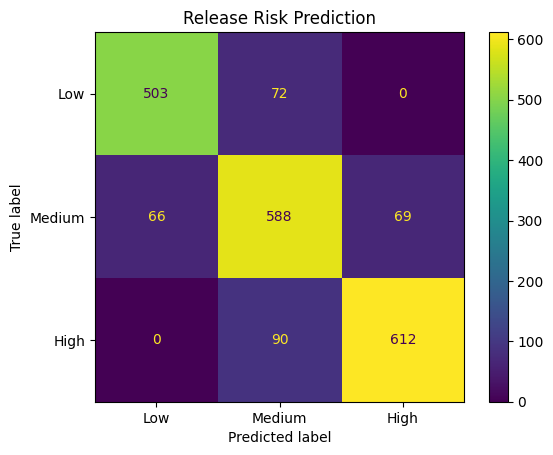


Top 20 Important Features
                   Feature  Importance
14    production_incidents    0.090465
19           quality_index    0.088986
8           defect_density    0.086600
13          rollback_count    0.073390
21            risk_density    0.051216
10       security_findings    0.048764
22          incident_ratio    0.043107
25    technical_debt_index    0.035854
17  integration_complexity    0.030359
11            failed_tests    0.029285
24        automation_score    0.023835
9           technical_debt    0.019837
4     developer_experience    0.018975
23      test_effectiveness    0.018359
5    automation_percentage    0.017864
34      release_type_Major    0.017687
1       release_complexity    0.016008
16  requirement_volatility    0.015873
0             release_size    0.015138
35      release_type_Minor    0.015058


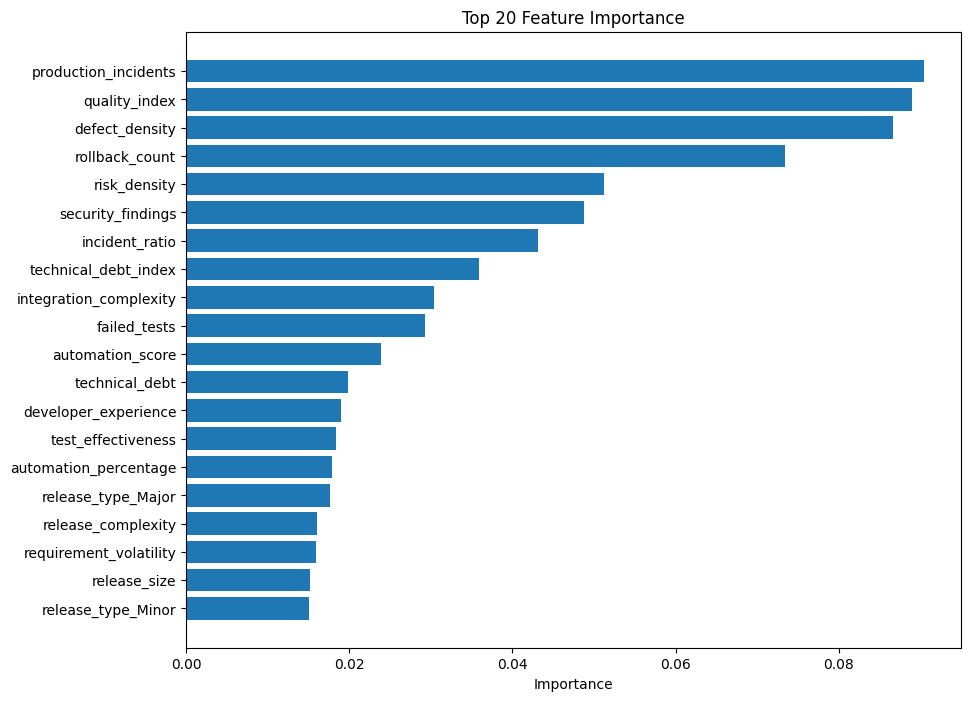


Model Saved Successfully
Predictions Saved Successfully

Release Model Training Completed


In [15]:
# ==========================================================
# PART 4
# RELEASE METRICS XGBOOST MODEL TRAINING
# ==========================================================

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

# ==========================================================
# LOAD DATA
# ==========================================================

df = pd.read_csv("release_feature_engineered.csv")

print("Dataset Loaded Successfully")
print(df.shape)

# ==========================================================
# TARGET
# ==========================================================

target = "release_risk_encoded"

# ==========================================================
# REMOVE LEAKAGE FEATURES
# ==========================================================

drop_columns = [

    "release_id",

    "release_date",

    "release_risk",

    "release_risk_encoded",

    # Used only for target generation
    "risk_score"

]

X = df.drop(columns=drop_columns)

y = df[target]

# ==========================================================
# ONE HOT ENCODING
# ==========================================================

categorical_columns = X.select_dtypes(include="object").columns

X = pd.get_dummies(

    X,

    columns=categorical_columns,

    drop_first=True

)

print("\nEncoded Dataset Shape :", X.shape)

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    stratify=y,

    random_state=42

)

print("Training :", len(X_train))
print("Testing :", len(X_test))

# ==========================================================
# MODEL
# ==========================================================

model = XGBClassifier(

    objective="multi:softprob",

    num_class=3,

    random_state=42,

    eval_metric="mlogloss"

)

# ==========================================================
# GRID SEARCH
# ==========================================================

param_grid = {

    "max_depth":[4,6],

    "learning_rate":[0.05,0.10],

    "n_estimators":[200,300],

    "subsample":[0.8,1.0],

    "colsample_bytree":[0.8,1.0]

}

grid = GridSearchCV(

    estimator=model,

    param_grid=param_grid,

    cv=5,

    scoring="f1_weighted",

    n_jobs=-1,

    verbose=1

)

print("\nTraining XGBoost Model...")

grid.fit(X_train,y_train)

best_model = grid.best_estimator_

print("\nBest Parameters")

print(grid.best_params_)

# ==========================================================
# PREDICTION
# ==========================================================

predictions = best_model.predict(X_test)

# ==========================================================
# METRICS
# ==========================================================

accuracy = accuracy_score(

    y_test,

    predictions

)

print("\nAccuracy")

print(round(accuracy*100,2),"%")

print("\nClassification Report")

print(

    classification_report(

        y_test,

        predictions

    )

)

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(

    y_test,

    predictions

)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=[

        "Low",

        "Medium",

        "High"

    ]

)

disp.plot()

plt.title("Release Risk Prediction")

plt.show()

# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":best_model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

print("\nTop 20 Important Features")

print(importance.head(20))

plt.figure(figsize=(10,8))

plt.barh(

    importance.head(20)["Feature"],

    importance.head(20)["Importance"]

)

plt.gca().invert_yaxis()

plt.xlabel("Importance")

plt.title("Top 20 Feature Importance")

plt.show()

# ==========================================================
# SAVE MODEL
# ==========================================================

joblib.dump(

    best_model,

    "best_release_xgb_model.pkl"

)

joblib.dump(

    X.columns,

    "release_features.pkl"

)

print("\nModel Saved Successfully")

# ==========================================================
# SAVE PREDICTIONS
# ==========================================================

prediction_df = pd.DataFrame({

    "Actual":y_test,

    "Predicted":predictions

})

prediction_df.to_csv(

    "release_predictions.csv",

    index=False

)

print("Predictions Saved Successfully")

print("\nRelease Model Training Completed")

In [17]:
print((release_df["risk_score"] < 55).mean())

print((release_df["risk_score"] < 95).mean())

0.2875
0.6488
